### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics

In [11]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Read Data

In [3]:
df = pd.read_csv('./data/Tesla.csv')

In [4]:
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [5]:
df.shape

(1692, 7)

In [7]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


### Step 3: Exploratory Data Analysis

Text(0, 0.5, 'Price in dollars.')

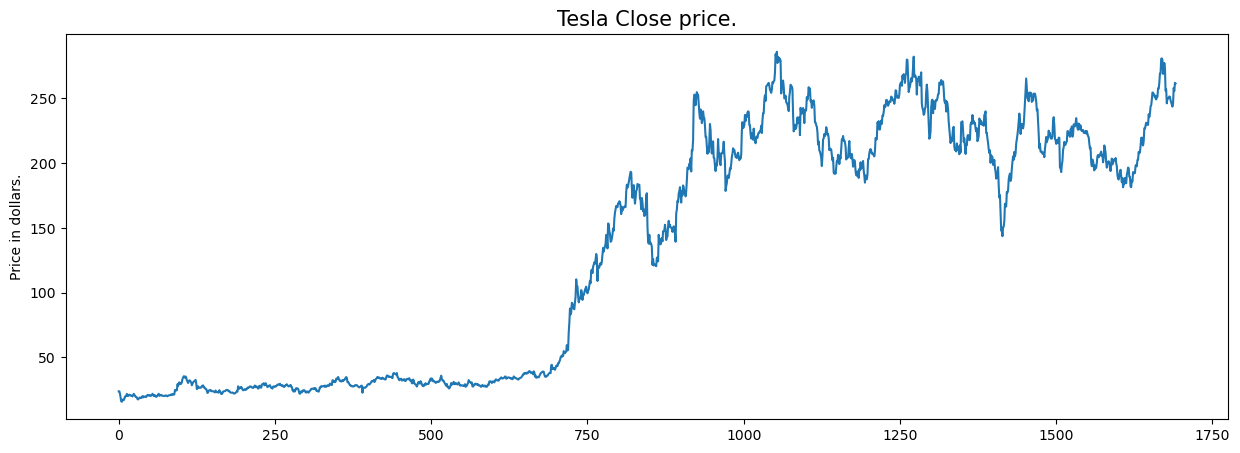

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(df['Close'])
plt.title('Tesla Close price.', fontsize=15)
plt.ylabel('Price in dollars.')

In [9]:
df = df.drop(['Adj Close'], axis=1)

In [10]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

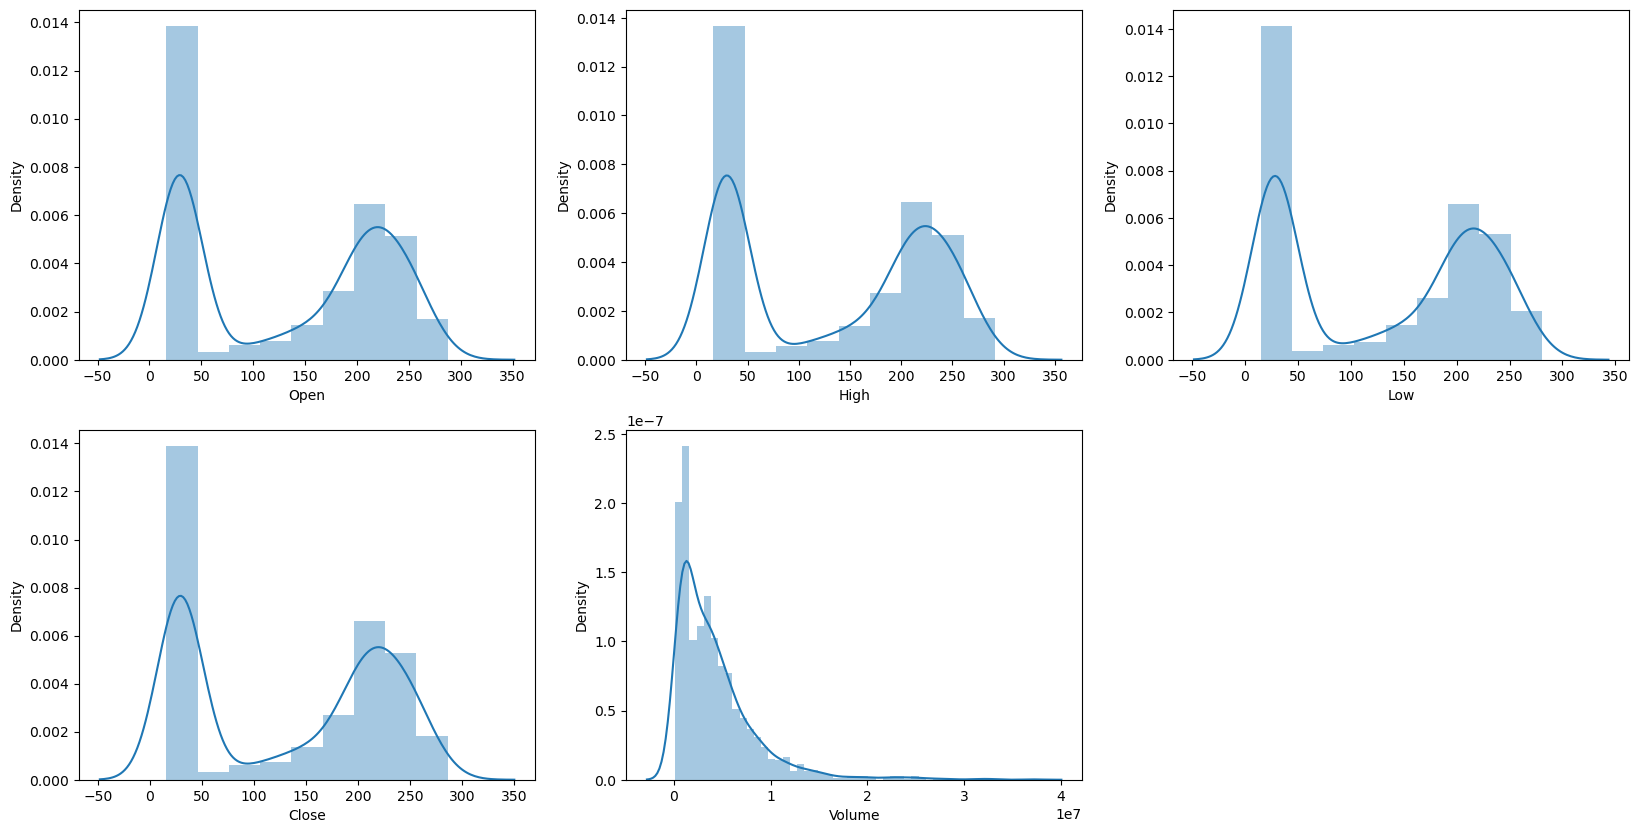

In [20]:
plt.figure(figsize=(20, 10))
for i, col in enumerate(df.columns[1:]):
    plt.subplot(2, 3, i+1)
    sns.distplot(df[col])

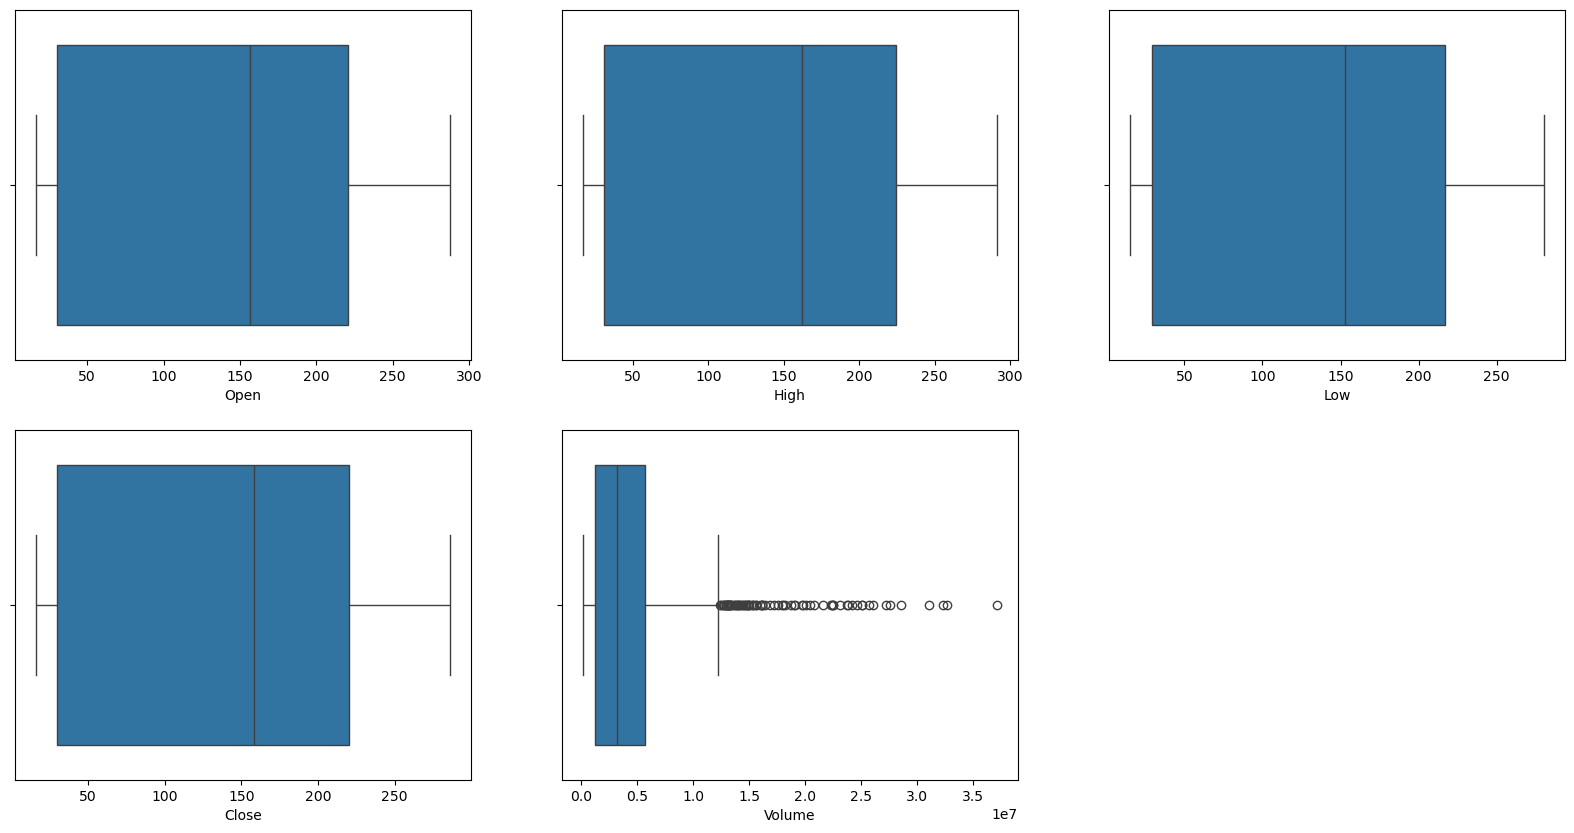

In [21]:
plt.figure(figsize=(20, 10))
for i, col in enumerate(df.columns[1:]):
    plt.subplot(2, 3, i+1)
    sns.boxplot(df[col], orient='h')

### Step 4: Feature Engineering

In [22]:
splitted = df['Date'].str.split('/', expand=True)

In [25]:
df['day'] = splitted[1].astype(np.int16)
df['month'] = splitted[0].astype(np.int16)
df['year'] = splitted[2].astype(np.int16)

In [27]:
df['is_quarter_end'] = np.where(df['month']%3==0, 1, 0)

In [28]:
df.head()

,Date,Open,High,Low,Close,Volume,day,month,year,is_quarter_end
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,29,6,2010,1
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,30,6,2010,1
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,1,7,2010,0
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,2,7,2010,0
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,6,7,2010,0


In [29]:
df['open-close']  = df['Open'] - df['Close']
df['high-low']  = df['High'] - df['Low']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

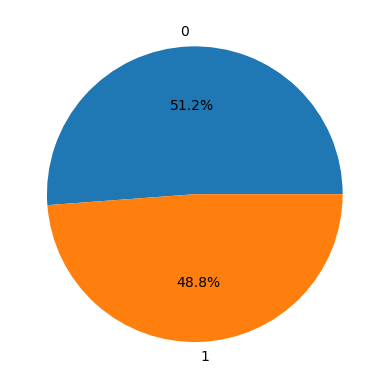

In [31]:
_ = plt.pie(df['target'].value_counts().values, labels=[0, 1], autopct='%1.1f%%')

<Axes: >

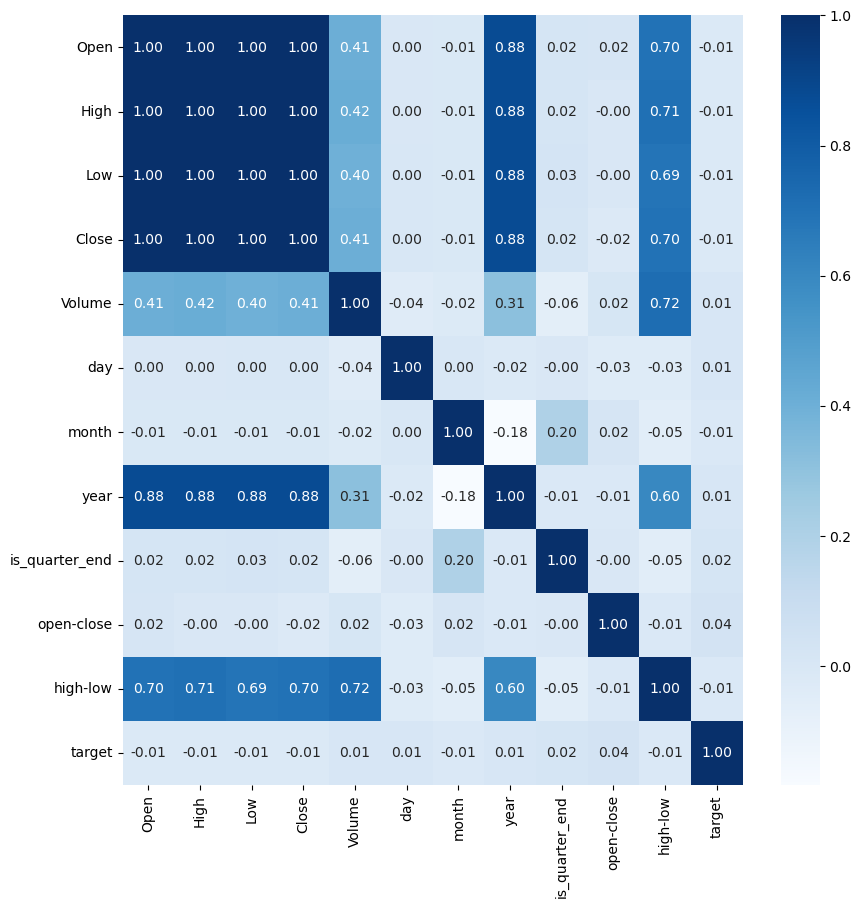

In [36]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.drop(['Date'], axis=1).corr(), annot=True, fmt='.2f', cmap=plt.cm.Blues)

### Step 5: Splitting and Normalization

In [37]:
features = df[['open-close', 'high-low', 'is_quarter_end']]
target = df['target']

In [38]:
scaler = StandardScaler()

In [39]:
features = scaler.fit_transform(features)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

### Step 6: Model Development and Evaluation

In [41]:
models = [LogisticRegression(), SVC(kernel='poly', probability=True), XGBClassifier()]

In [42]:
for model in models:
    model.fit(X_train, y_train)
    print(model, ':')
    print('Training Accuracy:', metrics.roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]))
    print('Test Accuracy:', metrics.roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
    print('----------------')

LogisticRegression() :
Training Accuracy: 0.5212864161558889
Test Accuracy: 0.5023673583066426
----------------
SVC(kernel='poly', probability=True) :
Training Accuracy: 0.47596063402064115
Test Accuracy: 0.5042473193148587
----------------
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...

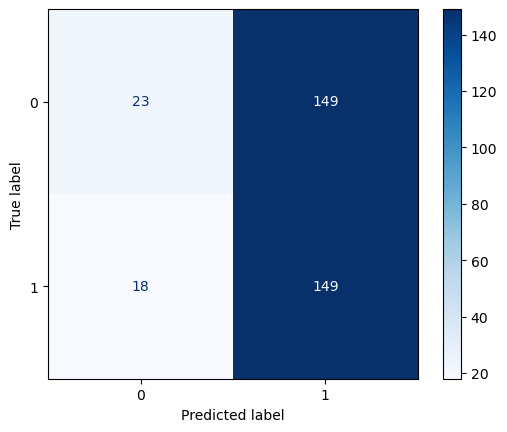

In [48]:
metrics.ConfusionMatrixDisplay.from_estimator(models[0], X_test, y_test, cmap=plt.cm.Blues)